# Titanic — Estratégia 1: remover atributos com muitas ausências

Nesta versão:
- Removemos `boat`, `body`, `cabin` e `home.dest`.
- Depois removemos as poucas instâncias que ainda possuem valores ausentes;

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("titanic completo.csv")
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## Dados ausentes

In [3]:
print("Dimensão original:", df.shape)
print("\nValores ausentes por atributo:")
print(df.isna().sum().sort_values(ascending=False))

Dimensão original: (1309, 14)

Valores ausentes por atributo:
body         1188
cabin        1014
boat          823
home.dest     564
age           263
embarked        2
fare            1
pclass          0
survived        0
name            0
sex             0
sibsp           0
parch           0
ticket          0
dtype: int64


## Remoção dos atributos indicados

In [4]:
atributos_remover = ["boat", "body", "cabin", "home.dest"]

df_limpo = df.drop(columns=atributos_remover).copy()
df_limpo = df_limpo.dropna()

print("Dimensão após o tratamento:", df_limpo.shape)
print("Total de valores ausentes:", df_limpo.isna().sum().sum())

Dimensão após o tratamento: (1043, 10)
Total de valores ausentes: 0


## Visualizações

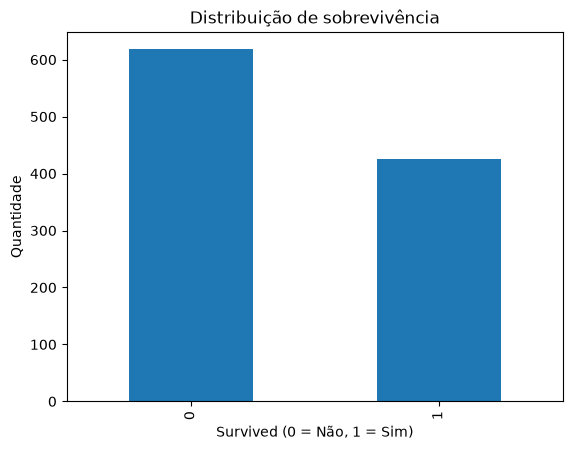

In [5]:
df_limpo["survived"].value_counts().sort_index().plot(
    kind="bar",
    title="Distribuição de sobrevivência"
)
plt.xlabel("Survived (0 = Não, 1 = Sim)")
plt.ylabel("Quantidade")
plt.show()

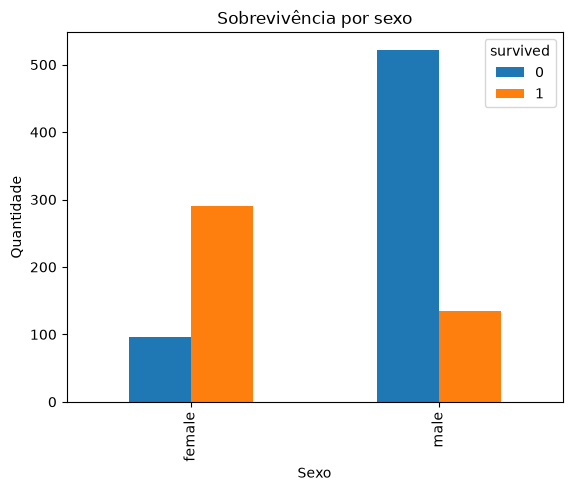

In [6]:
pd.crosstab(df_limpo["sex"], df_limpo["survived"]).plot(
    kind="bar",
    title="Sobrevivência por sexo"
)
plt.xlabel("Sexo")
plt.ylabel("Quantidade")
plt.show()

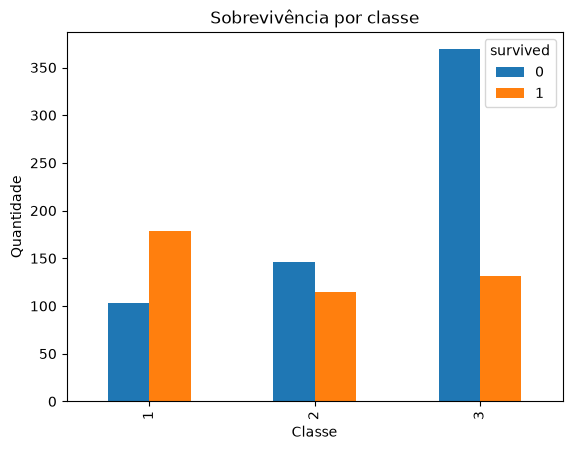

In [7]:
pd.crosstab(df_limpo["pclass"], df_limpo["survived"]).plot(
    kind="bar",
    title="Sobrevivência por classe"
)
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

## Preparação dos dados

`name` e `ticket` são retirados do treinamento por funcionarem principalmente como identificadores.

In [8]:
X = df_limpo.drop(columns=["survived", "name", "ticket"])
y = df_limpo["survived"]

X = pd.get_dummies(X, drop_first=False, dtype=int)

print("Quantidade de atributos após codificação:", X.shape[1])
X.head()

Quantidade de atributos após codificação: 10


,pclass,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,1,29.00,0,0,211.3375,1,0,0,0,1
1,1,0.92,1,2,151.5500,0,1,0,0,1
2,1,2.00,1,2,151.5500,1,0,0,0,1
3,1,30.00,1,2,151.5500,0,1,0,0,1
4,1,25.00,1,2,151.5500,1,0,0,0,1


## Divisão em treino e teste

In [9]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treino:", X_treino.shape)
print("Teste:", X_teste.shape)

Treino: (834, 10)
Teste: (209, 10)


## Árvore de decisão

In [10]:
arvore = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

arvore.fit(X_treino, y_treino)

y_pred = arvore.predict(X_teste)

print("Acurácia:", accuracy_score(y_teste, y_pred))
print("\nMatriz de confusão:")
print(confusion_matrix(y_teste, y_pred))
print("\nRelatório:")
print(classification_report(y_teste, y_pred, target_names=["Não sobreviveu", "Sobreviveu"]))

Acurácia: 0.7320574162679426

Matriz de confusão:
[[98 26]
 [30 55]]

Relatório:
                precision    recall  f1-score   support

Não sobreviveu       0.77      0.79      0.78       124
    Sobreviveu       0.68      0.65      0.66        85

      accuracy                           0.73       209
     macro avg       0.72      0.72      0.72       209
  weighted avg       0.73      0.73      0.73       209



## Visualização da árvore

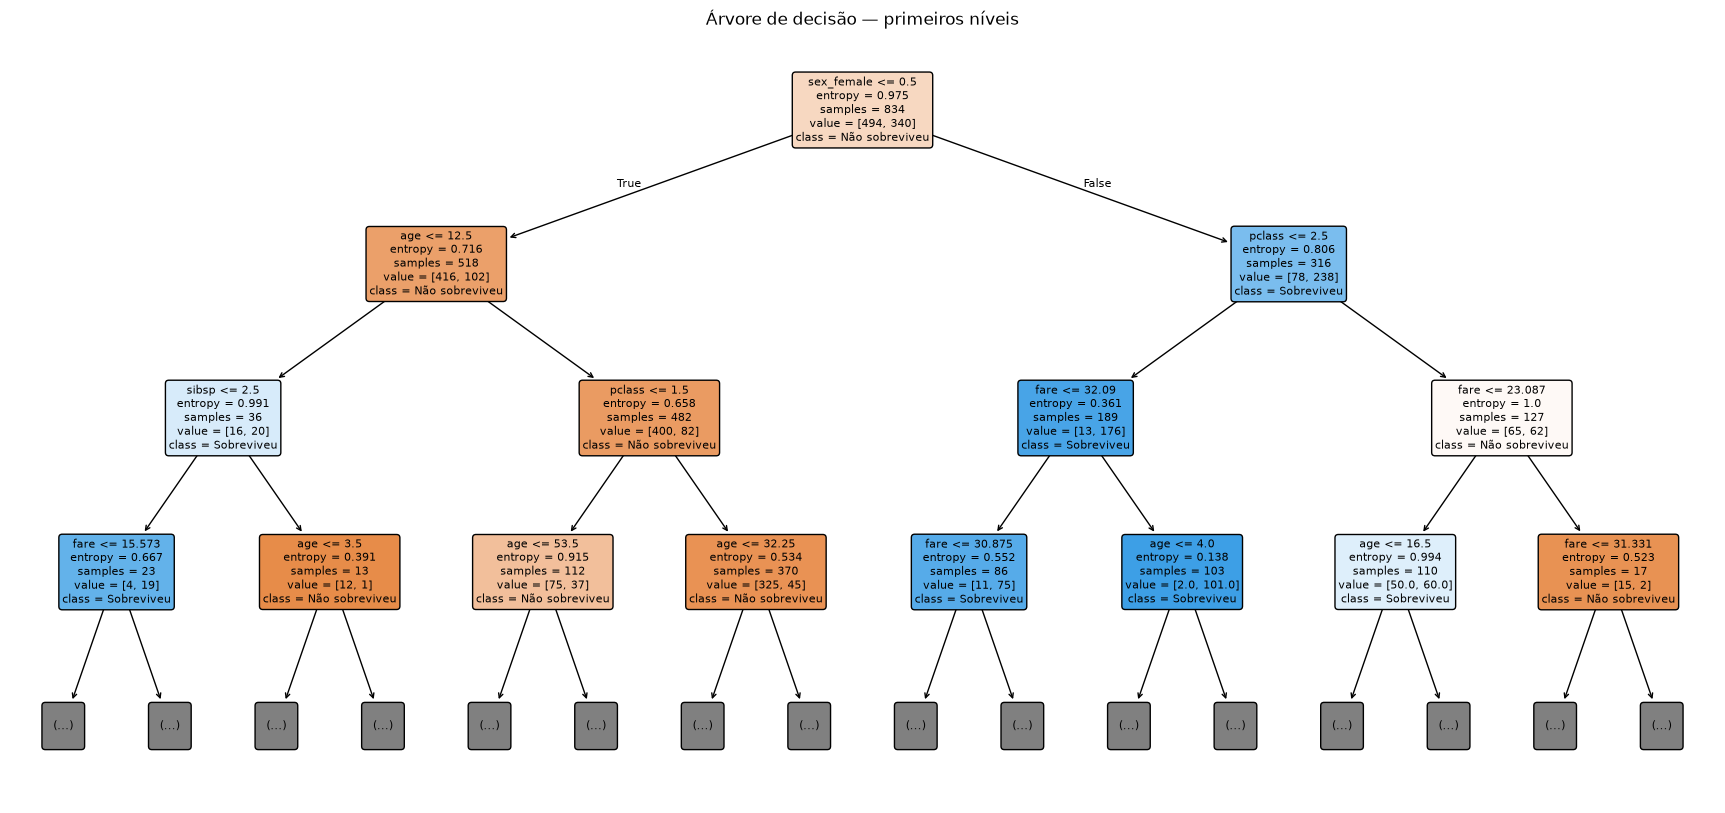

In [11]:
plt.figure(figsize=(22, 10))
plot_tree(
    arvore,
    feature_names=X.columns,
    class_names=["Não sobreviveu", "Sobreviveu"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Árvore de decisão — primeiros níveis")
plt.show()

## Regras da árvore

In [12]:
regras = export_text(
    arvore,
    feature_names=list(X.columns),
    max_depth=4
)
print(regras)

|--- sex_female <= 0.50
|   |--- age <= 12.50
|   |   |--- sibsp <= 2.50
|   |   |   |--- fare <= 15.57
|   |   |   |   |--- fare <= 13.12
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- fare >  13.12
|   |   |   |   |   |--- class: 0
|   |   |   |--- fare >  15.57
|   |   |   |   |--- class: 1
|   |   |--- sibsp >  2.50
|   |   |   |--- age <= 3.50
|   |   |   |   |--- age <= 2.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- age >  2.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- age >  3.50
|   |   |   |   |--- class: 0
|   |--- age >  12.50
|   |   |--- pclass <= 1.50
|   |   |   |--- age <= 53.50
|   |   |   |   |--- age <= 52.50
|   |   |   |   |   |--- truncated branch of depth 15
|   |   |   |   |--- age >  52.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- age >  53.50
|   |   |   |   |--- age <= 75.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- age >  75.50
|   |   |   |   |   |--- class: 1
|   |   |--- pclass >  1.50